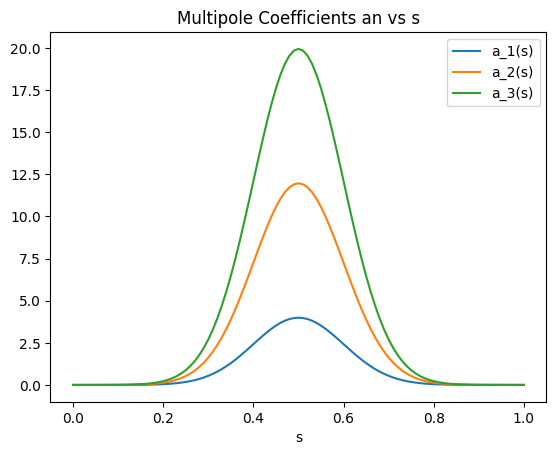

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial

def gaussian(x, mu, sig):
    return (
        1.0 / (np.sqrt(2.0 * np.pi) * sig) * np.exp(-np.power((x - mu) / sig, 2.0) / 2)
    )
#define a_n, b_n multipole components (uniform in s)


#define x axis
x = np.linspace(-1, 1, 101)
s= np.linspace(0, 1, 101)
a_n = np.zeros((4,len(s)))
b_n = np.zeros((4,len(s)))
a_n[0,:]=np.zeros(len(s))
a_n[1,:]=gaussian(s, 0.5, 0.1)
a_n[2,:]=3*gaussian(s, 0.5, 0.1)
a_n[3,:]=5*gaussian(s, 0.5, 0.1)
plt.plot(s, a_n[1,:], label='a_1(s)')
plt.plot(s, a_n[2,:], label='a_2(s)')
plt.plot(s, a_n[3,:], label='a_3(s)')
plt.xlabel('s')
plt.legend()
plt.title('Multipole Coefficients an vs s')
plt.show()

The field on axis can then be computed using 

$B_x(x, y=0, s) = \sum_{n=1}^\infty a_n(s) \frac{x^{n-1}}{(n-1)!} $

and 


$B_y(x, y=0, s) = \sum_{n=1}^\infty b_n(s) \frac{x^{n-1}}{(n-1)!}$

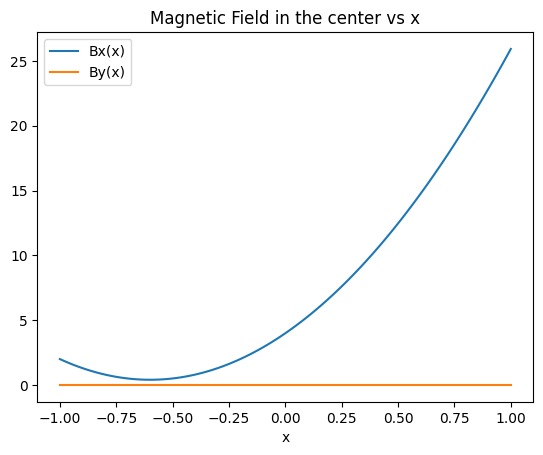

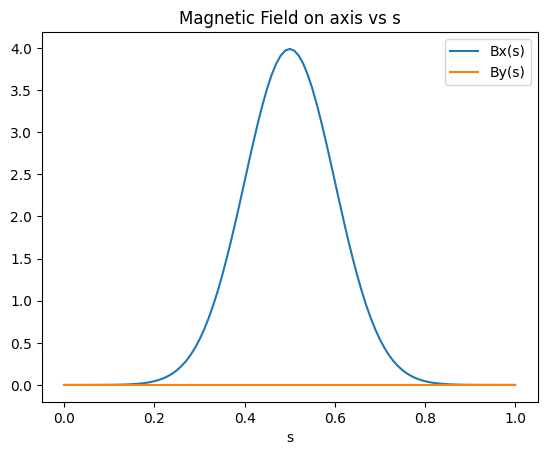

In [36]:
def BxofxandsfromMultipole(x, a_n, b_n): 
    Bx = np.zeros((len(x),len(s)))
    for i in range(len(x)):
        for n in range(1, len(a_n)):
            Bx[i,:] += a_n[n,:]*x[i]**(n-1) / factorial(n-1)
    return Bx
def ByofxandsfromMultipole(x, a_n, b_n):
    By = np.zeros((len(x),len(s)))
    for i in range(len(x)):
        for n in range(1, len(b_n)):
            By[i,:] += b_n[n,:]*x[i]**(n-1) / factorial(n-1)
    return By
Bx=BxofxandsfromMultipole(x, a_n, b_n) 
By=ByofxandsfromMultipole(x, a_n, b_n)
plt.plot(x, Bx[:,50])
plt.plot(x, By[:,50])
plt.xlabel('x')
plt.legend(['Bx(x)', 'By(x)'])
plt.title('Magnetic Field in the center vs x')           
plt.show()
plt.plot(s, Bx[50,:])
plt.plot(s, By[50,:])
plt.xlabel('s')
plt.legend(['Bx(s)', 'By(s)'])
plt.title('Magnetic Field on axis vs s') 
plt.show()

Now we can go back to the multipole components using 

$a_{n}(s) = \left. \partial^{n-1}_x B_x(x,y,s) \right|_{x=y=0}$

and

$ b_{n}(s) = \left. \partial^{n-1}_x B_y(x,y,s) \right|_{x=y=0} $

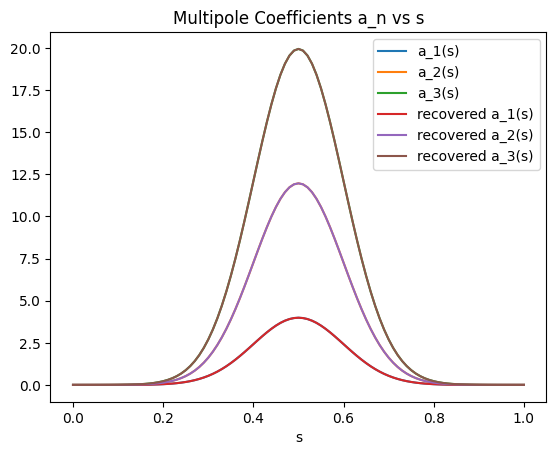

In [ ]:
def derivativesFromField(x, B, max_order):
    dBvector=np.zeros((max_order+1, len(B), len(s)))
    dBvector[0,:,:]=B
    for i in range(1,max_order+1):
        dBvector[i,:,:]=np.gradient(dBvector[i-1,:,:], x, axis=0)
    return dBvector
max_order = 3
idx_zero = np.argmin(np.abs(x))

dBxvector=derivativesFromField(x, Bx, max_order)
dByvector=derivativesFromField(x, By, max_order)

a_nnew=np.zeros_like(a_n)
b_nnew=np.zeros_like(b_n)
a_nnew[1:,:]=dBxvector[:max_order,idx_zero,:]
b_nnew[1:,:]=dByvector[:max_order,idx_zero,:]

plt.plot(s, a_n[1,:], label='a_1(s)')
plt.plot(s, a_n[2,:], label='a_2(s)')
plt.plot(s, a_n[3,:], label='a_3(s)')
plt.plot(s, a_nnew[1,:], label='recovered a_1(s)')
plt.plot(s, a_nnew[2,:], label='recovered a_2(s)')
plt.plot(s, a_nnew[3,:], label='recovered a_3(s)')
plt.xlabel('s')
plt.legend()
plt.title('Multipole Coefficients a_n vs s')
plt.show()
